<a href="https://colab.research.google.com/github/PovSobek/Manipuladores/blob/main/E03_IK_with_screws_theory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inverse kinematics with screws

Under the screw theory formalism and using the POE, the IK problem must obtain
the joints’ motion (i.e., magnitudes $\theta_{1}-\theta_{n}$),
knowing the configuration for the tool
pose (i.e., orientation and position).
The general solution to any manipulator IK problem follows this algorithm:


*   Select the Spatial coordinate system “S” (usually stationary and the base) and the Mobile coordinate system “T” (typically the tool).
*   Define the Axis of each joint, which are the axes $“\omega_{i}”$ for revolute joints and $“\upsilon_{i}”$ for the prismatic joints, and a point $“q_{i}”$ on those axes.
*   Obtain the Twists $“\xi_{i}”$ for the joints,
*   Get the pose of the tool at the reference $“H_{ST}(0)”$ (home) robot position.
*   Express the kinematics mapping $“H_{ST}(\theta)”$  with the product of all joint screw exponentials (POE) and $“H_{ST}(0)”$
*   Analyze the robot mechanics to recognize patterns of Canonical
Subproblems inside the POE expression for different sets of joints (i.e., one, two, or three)



#functions
functions needed:
(for charging in memory)

In [ ]:
import math #para poder usar math.pi y atan2
import numpy as np
from scipy.spatial.transform import Rotation as R

def joint2twist(Axis, Point, JointType):
  # los parametros son LISTAS, pero devuelve un array numpy
  if JointType == 'rot':
    aux = -np.cross(Axis, Point)
    twist = np.concatenate((aux, Axis), axis=0)
  elif JointType == 'tra':
    aux2 = [0, 0, 0]
    twist = np.concatenate((Axis, aux2), axis=0)
  else:
    twist = np.array([0, 0, 0, 0, 0, 0])
  return twist


def expScrew(TwMag):
  # Matrix Exponential of a  Rigid Body Motion by SCREW movement
  # "Twist-Mangitude" (TwMag) [xi; theta] (7x1)
  # Returns a homogeneous "H" matrix (4x4)
  v = np.array([TwMag[0], TwMag[1], TwMag[2]]) #TODO cambiar a slicing
  w = np.array([TwMag[3], TwMag[4], TwMag[5]]) #TODO cambiar a slicing
  theta = TwMag[6]
  if np.linalg.norm(w) == 0:
    R = np.eye(3)
    P = v.dot(theta)
    #print ("P: \n",P)
  else:
    R = expAxAng(np.append(w, theta))
    I = np.eye(3)
    #P_aux = np.matmul((I-R),(np.cross(w,v))) #OJO, falta el término + np.transpose(w*np.transpose(w)*v*theta)
    #P_aux = np.matmul((I-R),(np.cross(w,v)))
    P_aux = np.matmul((I-R),(np.cross(w,v)))+ np.transpose(w*np.transpose(w)*v*theta)
    #print ("P_aux \n", P_aux)
    P_aux2 = (I-R)@(np.cross(w,v)) #OJO, falta el término
    #print ("P_aux2 \n", P_aux2)
    #P = np.array([P_aux[0,0], P_aux[0,1], P_aux[0,2]])
    P = np.array([P_aux[0], P_aux[1], P_aux[2]])
    #print ("P = ", P)

  return np.array((
      (R[0,0], R[0,1], R[0,2], P[0]),
      (R[1,0], R[1,1], R[1,2], P[1]),
      (R[2,0], R[2,1], R[2,2], P[2]),
      (0, 0, 0, 1),
      )) #TODO mejor hacerlo con la funcion Hmatrix

def expAxAng(AxAng):
  '''
  RODRIGUES FORMULA - Exponential Matrix of a Rigid Body ORIENTATION
  AxAng is a 4x1  [x y z theta] == [W theta] (1x4)
  '''
  axis = np.array(AxAng[:3]) #asi seria un array numpy
  #print("axis: ", axis)
  u = axis2skew(axis)
  #print("u matrix: \n", u, u.dtype)
  theta = AxAng[3]
  I = np.eye(3)
  A = I + u*np.sin(theta)  + u@u*(1-np.cos(theta)) #expresion general de la formula de Rodrigues
  return A

def axis2skew(u):
  # Generate a skew symmetric matrix from a vector (axis u)
  return np.array([
      [0.0, -u[2], u[1]],
      [u[2], 0.0, -u[0]],
      [-u[1], u[0], 0.0]
      ])



#Paden-Kahan 1 PK1
The movement is defined by the rotation of a point $p$ around an axis $\omega$ so that the point passes to occupy the position of another point $k$


\begin{equation}
 e^{\tilde{\xi}\theta}p = k
\end{equation}

\begin{equation}
 u = p -r ; u_{p} = u- \omega \omega^{T}u; \nu = k-r; \nu_{p} = \nu - \omega \omega^{T} \nu
 \end{equation}

\begin{equation}
 \theta = atan2\left(\omega^{T}(u_{p} \times \nu_{p}), u^{T}_{p} \cdot \nu_{p}\right)
 \end{equation}

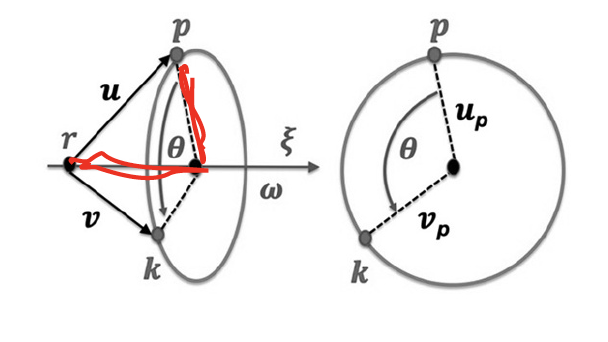


In [ ]:
def PadenKahanOne(x1, pp, pk):
    #v1 = x1(1:3); w1 = x1(4:6);
    v1 = x1[0:3]
    w1 = x1[3:6]
    #r1 = cross(w1,v1)/(norm(w1)^2);
    aux1 = np.cross(w1,v1)
    #print("aux1: ",aux1)
    aux2 = np.linalg.norm(w1)
    r1 = aux1 / (pow(aux2,2))
    #u = pp-r1; up = u-w1*w1'*u;
    u = pp - r1
    up = u - w1 * w1.T * u
    #v = pk-r1; vp = v-w1*w1'*v;
    v = pk - r1
    vp = v - w1 * w1.T * v
    #Theta1 = atan2(w1'*(cross(up,vp)),up'*vp);
    aux3 = np.cross(up,vp)
    aux4 = np.dot(w1.T,aux3)
    aux5 = np.dot(up.T,vp)
    Theta1 = math.atan2(aux4,aux5)
    return Theta1

In [ ]:
# exercise 4_3_2
# creamos un punto generico, una magnitud del twist y un giro alrededor del eje Y
pp = 10 * np.random.rand(3)
print( "pp: ", pp)
pph = np.append(pp.T, [1])
#print( "pph: ", pph )
Mag = (np.random.rand(1)-np.random.rand(1))*2*math.pi
print ("MagRandom = ", Mag)
Axis = [0, 1, 0]
Point = [0, 0, 0]
Twist= joint2twist(Axis, Point, 'rot')
print( "Twist: ", Twist )
# STEP1: Apply ForwardKinemats to the Screw for "whatever" Mag
aux1 = np.append(Twist,Mag)
Et1 = expScrew(aux1)
#print( "Et1: ", Et1)
pk1h = np.dot(Et1, pph)
#pk1h = Et1 @ pph
#print ("pk1h : \n", pk1h)
pk1h = np.array(pk1h) # ???
#print ("pk1h : \n", pk1h)
pk1 = np.delete(pk1h, 3)
print ("pk1 : \n",pk1)
# STEP2: Calculate the IK solution by PK1 getting the magnitud Theta11
Theta1 = PadenKahanOne(Twist, pp, pk1)
print ("Theta = ",Theta1)
# STEP3: Test the PKP1 solution applying ForwardKinemats to the Screw
aux2 = np.append(Twist,Theta1)
Et2 = expScrew(aux2)
pk2h = np.dot(Et2, pph)
pk2h = np.array(pk2h) # ???
pk2 = np.delete(pk2h, 3)
print ("pk2 : \n",pk2)

# Paden-Kahan 2. PK2

This subproblem movement has a first rotation of a point $p$ around an axis $ω_{2}$ and then followed by a second rotation around an axis $ω_{1}$ so that the point passes to occupy the position given by another point $k$.

The axes $ω_{2}$ and $ω_{1}$ cross at some point $r$.

\begin{equation}
 e^{\tilde{\xi_{1}}\theta_{1}}e^{\tilde{\xi_{2}}\theta_{2}}p = k
\end{equation}


\begin{equation}
 u = p -r
\end{equation}
\begin{equation}
 v = k -r
\end{equation}
\begin{equation}
 \alpha = \frac{(\omega_{1}^{T}\omega_{2})\omega_{2}^{T}u-\omega_{1} v^{T}}{(\omega_{1}^{T}\omega_{2})^{2}-1}
\end{equation}
\begin{equation}
 \beta = \frac{(\omega_{1}^{T}\omega_{2})\omega_{1}^{T}u-\omega_{2} u^{T}}{(\omega_{1}^{T}\omega_{2})^{2}-1}
\end{equation}
\begin{equation}
 \gamma^{2} = \frac{\lVert u \rVert^{2} - \alpha^{2} - \beta^{2} - 2\alpha\beta\omega_{1}^{T}\omega_{2}}{\lVert \omega_{1} \times \omega_{2} \rVert^{2}}
\end{equation}


Therefore, the IK solution needs to find points $c$ and $d$ in any 3D case.
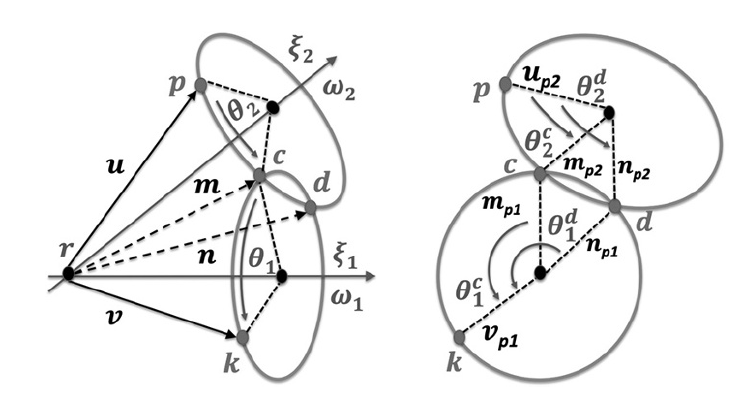


In [ ]:
def PadenKahanTwo(x1, x2, pp, pk):
  v1 = x1[0:3]
  w1 = x1[3:6]
  v2 = x2[0:3]
  w2 = x2[3:6]
  aux1 = np.cross(w1,v1)
  aux2 = np.linalg.norm(w1)
  r1 = aux1 / (pow(aux2,2))
  aux3 = np.cross(w2,v2)
  aux4 = np.linalg.norm(w2)
  r2 = aux3 / (pow(aux4,2))

  # EN EL CODIGO DE MATLAB HAY UN PASO PARA ASEGURAR QUE INTERSECTAN intersectLines3D (todo)
  # para el ejercicio 4_3_3 nos vale pr = ([0, 0 , 0])
  pr = np.array([0, 0 , 0])
  u = pp - pr
  #print ("u: ", u)
  v = pk - pr
  #print ("v: ", v)
  Cw1w2 = np.cross(w1,w2);
  #print ("Cw1w2: ", Cw1w2)
  #a = ((w1'*w2)*w2'*u-w1'*v)/((w1'*w2)^2-1);
  aux5 = np.dot(w1.T,w2)
  aux6 = np.dot(w2.T,u)
  aux7 = np.dot(w1.T,v)
  numerador_a = aux5*aux6-aux7
  denominador = pow(np.dot(w1.T,w2),2)-1
  a = numerador_a / denominador
  #print ("a: ", a)
  #b = ((w1'*w2)*w1'*v-w2'*u)/((w1'*w2)^2-1);
  aux8 = np.dot(w1.T,v)
  aux9 = np.dot(w2.T,u)
  numerador_b = aux5*aux8-aux9
  denominador = pow(np.dot(w1.T,w2),2)-1
  b = numerador_b / denominador
  #print ("b: ", b)
  #g2 = abs(real((norm(u)^2-a^2-b^2-2*a*b*w1'*w2)/norm(Cw1w2)^2));
  g2aux1 = pow(np.linalg.norm(u),2)
  g2numerador = g2aux1 - pow(a,2) - pow(b,2) -2*a*b*w1.T*w2
  g2denominador = pow(np.linalg.norm(Cw1w2),2)
  g2 = g2numerador / g2denominador
  #g = sqrt(g2);
  g = np.sqrt(g2)
  #pc = pr + a*w1+b*w2+g*Cw1w2;
  pc = pr + a*w1+b*w2+g*Cw1w2;
  #print ("pc: ", pc)
  #pd = pr + a*w1+b*w2-g*Cw1w2;
  pd = pr + a*w1+b*w2-g*Cw1w2;
  #print ("pd: ", pd)
  m = pc - pr;
  n = pd - pr;
  #Solve the TWO DOUBLE SOLUTIONS using the PadenKahanOne
  up = u-w2*w2.T*u;
  m2p = m-w2*w2.T*m;
  m1p = m-w1*w1.T*m;
  n2p = n-w2*w2.T*n;
  n1p = n-w1*w1.T*n;
  vp = v-w1*w1.T*v;
  #t21 = atan2(real(w2'*(cross(up,m2p))),real(up'*m2p));
  t21_aux1 = np.cross(up,m2p)
  t21_aux2 = np.dot(w2.T,t21_aux1)
  t21_aux3 = np.dot(up.T,m2p)
  t21 = math.atan2(t21_aux2,t21_aux3)
  #print ("t21_aux2: ", t21_aux2)
  #t11 = atan2(real(w1'*(cross(m1p,vp))),real(m1p'*vp));
  t11_aux1 = np.cross(m1p,vp)
  t11_aux2 = np.dot(w1.T,t11_aux1)
  t11_aux3 = np.dot(m1p.T,vp)
  t11 = math.atan2(t11_aux2,t11_aux3)
  #print ("t11: ", t11)
  #t22 = atan2(real(w2'*(cross(up,n2p))),real(up'*n2p));
  t22_aux1 = np.cross(up,n2p)
  t22_aux2 = np.dot(w2.T,t22_aux1)
  t22_aux3 = np.dot(up.T,n2p)
  t22 = math.atan2(t22_aux2,t22_aux3)
  #print ("t22: ", t22)
  #t12 = atan2(real(w1'*(cross(n1p,vp))),real(n1p'*vp));
  t12_aux1 = np.cross(n1p,vp)
  t12_aux2 = np.dot(w1.T,t12_aux1)
  t12_aux3 = np.dot(n1p.T,vp)
  t12 = math.atan2(t12_aux2,t12_aux3)
  #print ("t12: ", t12)

  Theta1Theta2 = np.array([t11, t21, t12, t22])
  return Theta1Theta2

In [ ]:
# exercise 4_3_3
pp = 10 * np.random.rand(3)
print( "pp: ", pp)
pph = np.append(pp.T, [1])
pph = np.array(pph) # ???
#print( "pph: ", pph )
Mag = np.array([(np.random.rand(1)-np.random.rand(1))*2*math.pi, (np.random.rand(1)-np.random.rand(1))*2*math.pi])
print ("MagRandom = ", Mag)
p1 = [0, 0, 0]; p2 = [0, 0, 0]; # must imply the intersection of Twists
#Point = [p1, p2];
AxisX = [1, 0, 0]
AxisY = [0, 1, 0]
#AxisZ = [0, 0, 1] #descomentar si se quiere usar
#Now we build the TWISTS matrix for the chosen Joints
Twist1= joint2twist(AxisX, p1, 'rot')
Twist2= joint2twist(AxisY, p2, 'rot')
#print( "Twist1: ", Twist1 )
#print( "Twist2: ", Twist2 )
# STEP1: Apply ForwardKinemats to the Screw for "whatever" Mag
aux1 = np.append(Twist1,Mag[0])
aux2 = np.append(Twist2,Mag[1])
Et1 = expScrew(aux1)
Et2 = expScrew(aux2)
#print( "Et1: ", Et1)
#print( "Et2: ", Et2)
Et = np.dot(Et1, Et2)
pk1h = np.dot(Et, pph)
#print ("pk1h : \n", pk1h)
pk1h = np.array(pk1h) # ???
#print ("pk1h : \n", pk1h)
pk1 = np.delete(pk1h, 3)
print ("pk1 : \n",pk1)
# STEP2: Calculate the IK solution by PK2 getting the magnitud Theta1Theta2 = [t11 t21; t12 t22] DOUBLE SOLUTION.
Theta1Theta2 = PadenKahanTwo(Twist1, Twist2, pp, pk1)
print ("Theta1Theta2 = ",Theta1Theta2)
# STEP3: Test the TWO DOUBLE solutions by PK2 Theta1 & Theta2 applying ForwardKinemats to the Screws on pp and checking we get the same pk.
# solucion 1
aux3 = np.append(Twist1,Theta1Theta2[0])
aux4 = np.append(Twist2,Theta1Theta2[1])
Et3 = expScrew(aux3)
Et4 = expScrew(aux4)
HstR2 = np.dot(Et3, Et4)
pk2h = np.dot(HstR2, pph)
pk2h = np.array(pk2h) # ???
pk2 = np.delete(pk2h, 3)
print ("pk2 : \n",pk2)
# solucion 2
aux5 = np.append(Twist1,Theta1Theta2[2])
aux6 = np.append(Twist2,Theta1Theta2[3])
Et5 = expScrew(aux5)
Et6 = expScrew(aux6)
HstR3 = np.dot(Et5, Et6)
pk3h = np.dot(HstR3, pph)
pk3h = np.array(pk3h) # ???
pk3 = np.delete(pk3h, 3)
print ("pk3 : \n",pk3)

# Paden-Kahan 3. PK3

Rotation at a given distance applied to a point

This subproblem represents the rotation of a point $“p”$ around an axis $“\omega”$ so that the point passes to occupy the position given by the point $“c”$ or $“d$”. This motion must comply with the condition that the distance from either of those two points (i.e., $“c”$ or $“d”$) to a certain point $“k”$ in the 3D space is given by the magnitude $“\delta”$.

\begin{equation}
 \lVert e^{\tilde{\xi}\theta}p - k  \rVert = \delta
\end{equation}


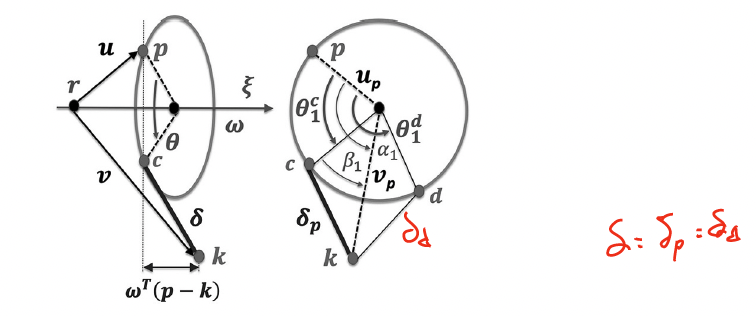

In [ ]:
def PadenKahanThree(x1, pp, pk, de):
    #print("de=", de)
    #v1 = x1(1:3); w1 = x1(4:6);
    v1 = x1[0:3]
    w1 = x1[3:6]
    #r1 = cross(w1,v1)/(norm(w1)^2);
    aux1 = np.cross(w1,v1)
    aux2 = np.linalg.norm(w1)
    r1 = aux1 / (pow(aux2,2))
    #u = pp-r1; up = u-w1*w1'*u; nup = norm(up);
    u = pp - r1
    up = u - w1 * w1.T * u
    nup = np.linalg.norm(up)
    #print("nup=", nup)
    #v = pk-r1; vp = v-w1*w1'*v; nvp = norm(vp);
    v = pk - r1
    vp = v - w1 * w1.T * v
    nvp = np.linalg.norm(vp)
    #print("nvp=", nvp)
    #alfa1 = atan2(real(w1'*(cross(up,vp))),real(up'*vp));
    aux3 = np.cross(up,vp)
    aux4 = np.dot(w1.T,aux3)
    aux5 = np.dot(up.T,vp)
    alpha1 = math.atan2(aux4,aux5)
    #print("alpha1=", alpha1)
    #dep2 = real(de^2-norm(w1'*(pp-pk))^2);
    dep2 = pow(de,2)-np.linalg.norm(w1.T*pow((pp-pk),2))
    #print("pow(de,2)", pow(de,2))
    #print("pow((pp-pk),2)", pow((pp-pk),2))
    #print("w1.T*pow((pp-pk),2)", w1.T*pow((pp-pk),2))
    #print("dep2=", dep2)
    #beta = (nup^2+nvp^2-dep2)/(2*nup*nvp);
    beta = (pow(nup,2)+pow(nvp,2)-dep2)/(2*nup*nvp)
    #print("beta=", beta)
    if beta > 1:
      beta = 1
    elif beta <(-1):
      beta = (-1)
    #beta1 = acos(beta);
    beta1 = np.arccos(beta)
    #print("beta1=", beta1)
    #Theta1 = [alfa1 - beta1; alfa1 + beta1];
    Theta1 = np.array([alpha1-beta1, alpha1+beta1])

    return Theta1

In [ ]:
# exercise 4_3_4
# creamos un punto generico, una magnitud del twist y un giro alrededor del eje Y
pp = 10 * np.random.rand(3)
print( "pp: ", pp)
pph = np.append(pp.T, [1])
#print( "pph: ", pph )
pk = 10 * np.random.rand(3)
print( "pk: ", pk)
pkh = np.append(pk.T, [1])
#print( "pkh: ", pkh )
Mag = (np.random.rand(1)-np.random.rand(1))*2*math.pi
print ("MagRandom = ", Mag)
Axis = [1, 0, 0]
Point = [0, 0, 0]
Twist= joint2twist(Axis, Point, 'rot')
#print( "Twist: ", Twist )
# STEP1: Apply ForwardKinemats to the Screw for "whatever" Mag
aux1 = np.append(Twist,Mag)
Et1 = expScrew(aux1)
#print( "Et1: ", Et1)
pc1h = np.dot(Et1, pph)
#print ("pc1h : \n", pc1h)
pc1h = np.array(pc1h) # ???
#print ("pc1h : \n", pc1h)
pc1 = np.delete(pc1h, 3)
#print ("pc1 : \n",pc1)
#de1 = norm(pk-pc1)
de1 = np.linalg.norm(pk-pc1)
print ("de1 = ",de1)
# STEP2: Calculate the IK solution by PK1 getting the magnitud Theta11
Theta1 = PadenKahanThree(Twist, pp, pk, de1)
print ("Theta = ",Theta1)
# STEP3: Test the PKP1 solution applying ForwardKinemats to the Screw
#solucion 1
aux2 = np.append(Twist,Theta1[0])
Et2 = expScrew(aux2)
pc2h = np.dot(Et2, pph)
pc2h = np.array(pc2h)# ???
pc2 = np.delete(pc2h, 3)
de2 = np.linalg.norm(pk-pc2)
print ("de2 = ",de2)
#solucion 2
aux3 = np.append(Twist,Theta1[1])
Et3 = expScrew(aux3)
pc3h = np.dot(Et3, pph)
pc3h = np.array(pc3h)# ???
pc3 = np.delete(pc3h, 3)
de3 = np.linalg.norm(pk-pc3)
print ("de3 = ",de3)

# example with IRB 120

now we put the code for solving the IK


In [ ]:
añglhañskghñakghañ
hodghañsodgkha
Theta3 = PadenKahanThree(Twist, pp, pk, de1)